# Branch 1 — Data Validity Audit (visualization)

> Người thực hiện: **Bách** | 14/08/2026 | theo chỉ đạo mentor "làm tiếp audit nhánh 1"
> Script nền: `train/audit_branch1_data_validity.py` → `report/metrics/audit_branch1/findings.json`
> File dữ liệu: `data/processed/branch1_train.csv` (67,796 dòng; train 54,236 / test 13,560)

Báo cáo này **trực quan hóa** các phát hiện của audit Branch 1 (phân phối lớp, trùng lặp
cross-split, SSRF/OS-cmd mislabel, và content-format duplication `/blog/index.php/2020/03`),
để mentor dễ nhìn thấy vấn đề trước khi quyết có sửa data hay không.

> Ghi chú: notebook chỉ **đọc + vẽ** (audit/evaluation), **không sửa** data hay model.
> Style figure theo chuẩn IEEE (số hiệu Fig., bảng màu an toàn màu, legend, trục rõ đơn vị).


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# project root = repo root (không phụ thuộc nơi chạy nbconvert)
def _find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "configs").is_dir():
            return p
    return start

project_root = _find_project_root()
os.chdir(project_root)
sys.path.insert(0, str(project_root))

# IEEE colorblind-safe palette + style
IEEE_BLUE = "#0072B2"
IEEE_ORANGE = "#E69F00"
IEEE_RED = "#D55E00"
IEEE_BLACK = "#000000"
IEEE_GREEN = "#009E73"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "legend.frameon": True,
    "legend.edgecolor": "0.7",
    "legend.fancybox": False,
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
})

# ---- load data ----
df = pd.read_csv(project_root / "data" / "processed" / "branch1_train.csv",
                 keep_default_na=False, na_values=[])

_SSRF_PATTERNS = ("owasp.org", "/etc/passwd", "shellshock")
_BLOG = "/blog/index.php/2020/03"

def is_ssrf(q):
    q = str(q).lower()
    return any(p in q for p in _SSRF_PATTERNS)

print(f"rows={len(df):,}  cols={list(df.columns)}")
print(f"split={df['split'].value_counts().to_dict()}")
print(f"labels={df['label_name'].value_counts().to_dict()}")


rows=67,796  cols=['id', 'query_raw', 'query_canonical', 'has_comment_marker', 'label', 'label_name', 'source', 'split']
split={'train': 54236, 'test': 13560}
labels={'time_blind': 15000, 'normal': 15000, 'boolean_blind': 15000, 'union_based': 15000, 'error_based': 7796}


## Mảng 1 — Phân phối lớp (5-class, cân bằng)

Dataset đúng **5 lớp**, không còn phantom `stacked` (config `exclude_labels: [5]`).
`normal / union_based / boolean_blind / time_blind` mỗi lớp 15,000; `error_based` 7,796
(source nhỏ hơn, giữ nguyên). Phân phối gần như cân bằng — điều kiện tốt để train
classifier multi-class.


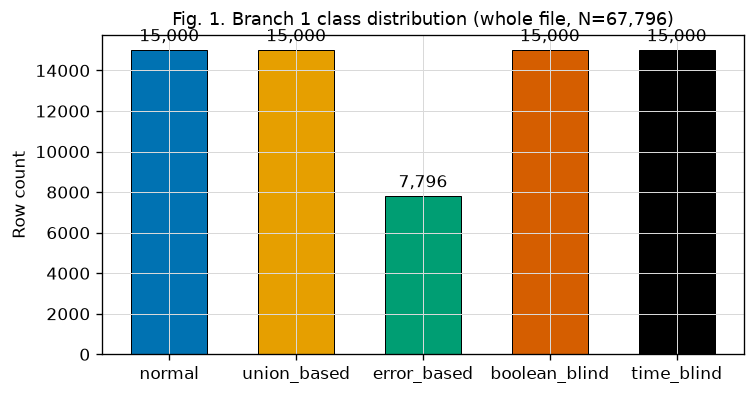

split          test  train
label_name                
boolean_blind  3000  12000
error_based    1560   6236
normal         3000  12000
time_blind     3000  12000
union_based    3000  12000


In [2]:
# Fig. 1 — Class distribution (whole file)
counts = df["label_name"].value_counts().reindex(
    ["normal", "union_based", "error_based", "boolean_blind", "time_blind"])
fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(counts.index, counts.values, width=0.6,
              color=[IEEE_BLUE, IEEE_ORANGE, IEEE_GREEN, IEEE_RED, IEEE_BLACK],
              edgecolor=IEEE_BLACK, linewidth=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 250, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("Row count")
ax.set_title("Fig. 1. Branch 1 class distribution (whole file, N=67,796)")
fig.tight_layout()
plt.show()

# split balance per class
pv = df.pivot_table(index="label_name", columns="split", values="id",
                    aggfunc="count", fill_value=0)
print(pv)


## Mảng 2 — Duplicate `query_canonical` & cross-split leakage

**4,277 dòng** là bản copy (của 2,741 text trùng nhau). Trong đó **949 text** xuất hiện ở
**cả train lẫn test** trong cùng file — đây là **leakage vector** cho eval Branch 1:
model có thể học thuộc text ở train rồi nhận lại đúng nó ở test.

Con số 4,277 **khớp chính xác** rule dedup trong `train/build_mlops_split.py`
("corpus has 4,277 repeated texts that otherwise straddle train and golden").


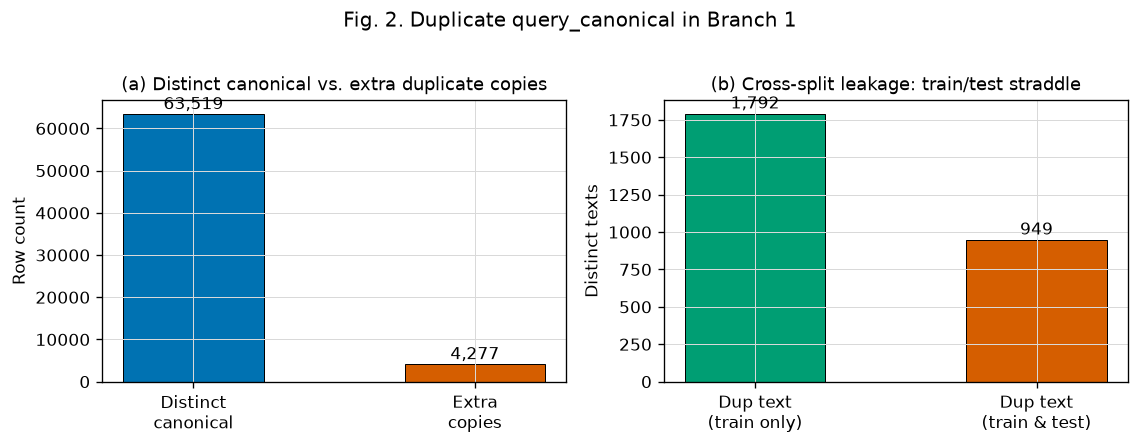

extra_copies=4,277  distinct_dup_texts=2,741  straddle_train_and_test=949


In [3]:
# Fig. 2 — Duplicate analysis
canon = df["query_canonical"]
n_extra = int(canon.duplicated(keep="first").sum())
dupe = df[canon.duplicated(keep=False)]
straddle = dupe.groupby("query_canonical")["split"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))

# (a) unique vs extra copies
labels = ["Distinct\ncanonical", "Extra\ncopies"]
vals = [int(canon.nunique()), n_extra]
bars = axes[0].bar(labels, vals, width=0.5, color=[IEEE_BLUE, IEEE_RED],
                   edgecolor=IEEE_BLACK, linewidth=0.6)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width()/2, v + 120, f"{v:,}", ha="center", va="bottom")
axes[0].set_ylabel("Row count")
axes[0].set_title("(a) Distinct canonical vs. extra duplicate copies")

# (b) straddle train/test
straddle_ct = {k: int((straddle == v).sum()) for k, v in [(1, 1), (2, 2)]}
n_straddle = straddle_ct.get(2, 0)
n_train_only = straddle_ct.get(1, 0)
labels = ["Dup text\n(train only)", "Dup text\n(train & test)"]
vals = [n_train_only, n_straddle]
bars = axes[1].bar(labels, vals, width=0.5, color=[IEEE_GREEN, IEEE_RED],
                   edgecolor=IEEE_BLACK, linewidth=0.6)
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width()/2, v + 8, f"{v:,}", ha="center", va="bottom")
axes[1].set_ylabel("Distinct texts")
axes[1].set_title("(b) Cross-split leakage: train/test straddle")

fig.suptitle("Fig. 2. Duplicate query_canonical in Branch 1", y=1.02)
fig.tight_layout()
plt.show()

print(f"extra_copies={n_extra:,}  distinct_dup_texts={int(dupe['query_canonical'].nunique()):,}  "
      f"straddle_train_and_test={n_straddle:,}")


## Mảng 3 — SSRF / OS-cmd mislabel & benign-pool contamination

**1,640 dòng** khớp pattern SSRF/OS-cmd callback (`owasp.org`, `/etc/passwd`, `shellshock`):

- **1,153 dòng nằm trong `normal`** — nhiễm bẩn benign pool (giống vấn đề SSRF Nhánh 2 đã lọc).
- **487 dòng bị gán nhầm vào `boolean_blind`** (lớp SQLi) — label noise, khớp ước lượng
  ~13% thủ công trong `data_contract.md` §3.1.


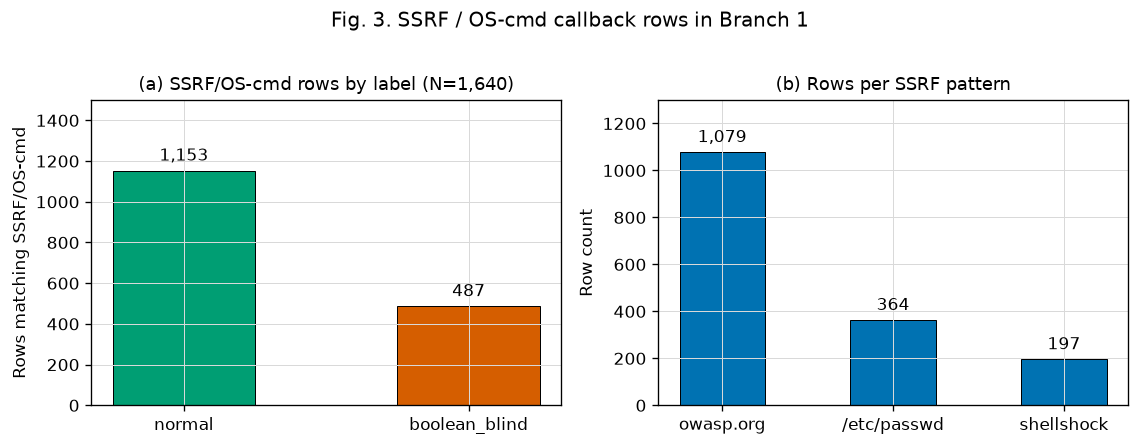

In [4]:
# Fig. 3 — SSRF / OS-cmd rows by label
m = df["query_canonical"].apply(is_ssrf)
ssrf_df = df[m]
by_label = ssrf_df["label_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))

# (a) SSRF rows by label
labels = ["normal", "boolean_blind"]
vals = [int(by_label.get("normal", 0)), int(by_label.get("boolean_blind", 0))]
bars = axes[0].bar(labels, vals, width=0.5, color=[IEEE_GREEN, IEEE_RED],
                   edgecolor=IEEE_BLACK, linewidth=0.6)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width()/2, v + 30, f"{v:,}", ha="center", va="bottom")
axes[0].set_ylabel("Rows matching SSRF/OS-cmd")
axes[0].set_title("(a) SSRF/OS-cmd rows by label (N=1,640)")
axes[0].set_ylim(0, 1500)

# (b) per-pattern totals
pats = {p: int(df["query_canonical"].str.lower().str.contains(p, na=False).sum())
        for p in _SSRF_PATTERNS}
bars = axes[1].bar(pats.keys(), list(pats.values()), width=0.5, color=IEEE_BLUE,
                   edgecolor=IEEE_BLACK, linewidth=0.6)
for b, v in zip(bars, pats.values()):
    axes[1].text(b.get_x() + b.get_width()/2, v + 25, f"{v:,}", ha="center", va="bottom")
axes[1].set_ylabel("Row count")
axes[1].set_title("(b) Rows per SSRF pattern")
axes[1].set_ylim(0, 1300)

fig.suptitle("Fig. 3. SSRF / OS-cmd callback rows in Branch 1", y=1.02)
fig.tight_layout()
plt.show()


## Mảng 4 — Content-format duplication `/blog/index.php/2020/03`

**11,920 dòng (17.58% dataset)** chứa chuỗi `/blog/index.php/2020/03` — WordPress
request-format, chủ yếu rơi vào `union_based` (5,327) / `error_based` (3,444) /
`time_blind` (2,076). Hơn 1/6 dataset chia sẻ cùng format → model có thể "ăn may"
nhờ format chung thay vì học đa dạng payload thật. **Không phải lỗi data** (là request
thật) nhưng làm giảm độ đa dạng per-class.


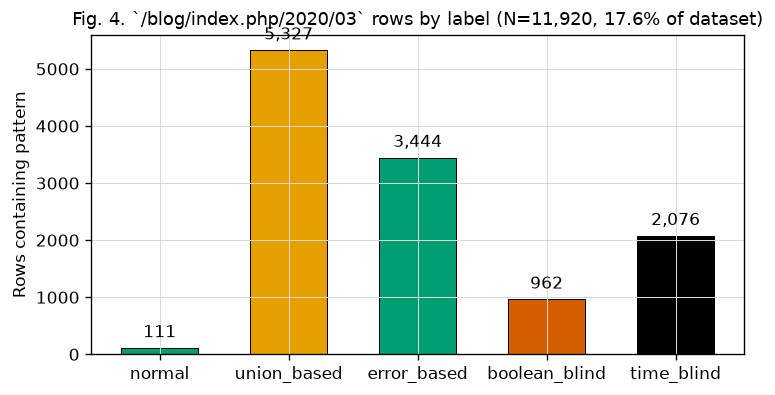

blog rows by source: {'d7_srbh2020': 11809, 'd7_srbh2020_normal': 111}
blog distinct canonicals: 11326


In [5]:
# Fig. 4 — /blog/index.php/2020/03 rows by label
blog = df["query_canonical"].str.contains(_BLOG, na=False)
blog_by_label = df.loc[blog, "label_name"].value_counts().reindex(
    ["normal", "union_based", "error_based", "boolean_blind", "time_blind"])

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(blog_by_label.index, blog_by_label.values, width=0.6,
              color=[IEEE_GREEN, IEEE_ORANGE, IEEE_GREEN, IEEE_RED, IEEE_BLACK],
              edgecolor=IEEE_BLACK, linewidth=0.6)
for b, v in zip(bars, blog_by_label.values):
    if v:
        ax.text(b.get_x() + b.get_width()/2, v + 120, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("Rows containing pattern")
ax.set_title(f"Fig. 4. `/blog/index.php/2020/03` rows by label (N={blog.sum():,}, "
             f"{blog.mean():.1%} of dataset)")
fig.tight_layout()
plt.show()

# per-source breakdown of blog rows
print("blog rows by source:", df.loc[blog, "source"].value_counts().to_dict())
print("blog distinct canonicals:", int(df.loc[blog, "query_canonical"].nunique()))


## Diễn giải

- **Mảng 1 (✅)**: phân phối 5 lớp cân bằng, không phantom `stacked` — nền tảng tốt.
- **Mảng 2 (❌)**: cross-split leakage **949 text** trùng ở cả train/test → eval
  `branch1_eval.json` có thể **lạc quan nhẹ** vì model ghi nhớ text ở train.
- **Mảng 3 (⚠️)**: **487 dòng SSRF trong `boolean_blind`** là label noise; **1,153 dòng
  SSRF trong `normal`** là nhiễm bẩn benign pool — cần lọc bằng `src/utils/ssrf.py`.
- **Mảng 4 (⚠️)**: **17.58% dataset** chung format `/blog/index.php/2020/03` — giảm đa dạng
  per-class, có thể làm model học format chung thay vì payload thật.

## Kết luận

- **Không cần thay đổi model** ở bước này — đây là audit/evaluation.
- **Đề xuất làm sạch data** (chờ mentor duyệt) áp dụng chuẩn Nhánh 2:
  1. **Dedup** `query_canonical` **trước khi split** train/test → loại vector cross-split leakage.
  2. **Lọc SSRF/OS-cmd** khỏi `normal` và `boolean_blind` bằng `src/utils/ssrf.py`.
  3. Re-train + re-eval → cập nhật `branch1_eval.json` (hiện F1-macro ≈ 0.9822).
- Sau khi clean, con số eval sẽ **trung thực hơn** (không bị phóng đại bởi leakage/noise).